# Audi Q4 e-tron — Price Prediction Model

**Goal:** Train and compare five regression models to predict the fair market listing price (`price_eur`) of a used Audi Q4 e-tron. Select the top two by cross-validated RMSE, tune both with Optuna, explain predictions with SHAP, and save the final models for use in the Deal Finder notebook.

**Run order:** This notebook must be run **before** `03_deal_finder.ipynb`.

**Models compared:**
1. Ridge Regression (linear baseline)
2. Random Forest Regressor
3. XGBoost Regressor
4. LightGBM Regressor
5. HistGradientBoosting Regressor (sklearn, NaN-native)

**Leakage exclusions:** `price_per_kw`, `price_per_hp`, `price_per_range_km` are derived from the target and must be removed.

In [1]:
# ── 1. Dependencies ────────────────────────────────────────────────────────────
import subprocess, sys
for pkg in ['scikit-learn', 'xgboost', 'lightgbm', 'optuna', 'shap']:
    try:
        __import__(pkg.replace('-', '_').split('[')[0])
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import warnings, json
from pathlib import Path
from datetime import datetime

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import KFold, cross_val_score, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

import shap

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 5)

RANDOM_STATE = 42
MODELS_DIR = Path('saved_models')
MODELS_DIR.mkdir(exist_ok=True)

DATA_PATH = Path('../Preprocessing/outputs/audi_q4_price_model_dataset.parquet')
print('All imports OK.')
print(f'Data path exists: {DATA_PATH.exists()}')


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


All imports OK.
Data path exists: True


## 1. Load Data & Feature Definitions

In [2]:
df = pd.read_parquet(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'Target stats:\n{df["price_eur"].describe().round(0)}')

# ── Feature definitions ────────────────────────────────────────────────────────
LEAKAGE_COLS = ['price_per_kw', 'price_per_hp', 'price_per_range_km']
ID_COLS      = ['listing_id']
TARGET       = 'price_eur'

NUMERIC_FEATURES = [
    'mileage_km', 'vehicle_age_months', 'power_kw', 'power_hp',
    'electric_range_km', 'wltp_consumption_kwh_100km',
    'seller_rating_stars', 'seller_rating_count',
    'image_count', 'previous_owner_count', 'door_count', 'seat_count',
    'warranty_months', 'mileage_per_month',
]

CATEGORICAL_ORDINAL = ['model_number_v2']   # naturally ordered: 35<40<45<50<55
CATEGORICAL_NOMINAL = [
    'variant', 'seller_type', 'body_type', 'paint_type',
    'exterior_color', 'interior_color', 'upholstery_material',
]

BINARY_FEATURES = [
    'is_conditional_price_clean', 'available_now_clean',
    'warranty_exists_clean', 'has_full_service_history_clean', 'had_accident_clean',
    'is_sportback', 'is_quattro', 'is_s_line',
    'has_matrix', 'has_pano', 'has_ahk', 'has_hud', 'has_acc', 'has_camera',
    'duplicate_listing_id', 'seller_has_rating',
    'has_warranty_months', 'has_battery_info', 'has_city_range', 'has_charging_time',
]

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_ORDINAL + CATEGORICAL_NOMINAL + BINARY_FEATURES

# Verify all feature columns exist
missing_cols = [c for c in ALL_FEATURES if c not in df.columns]
assert not missing_cols, f'Missing columns: {missing_cols}'

X = df[ALL_FEATURES].copy()
y = df[TARGET].copy()

print(f'\nFeatures: {len(ALL_FEATURES)} total')
print(f'  Numeric:    {len(NUMERIC_FEATURES)}')
print(f'  Ordinal:    {len(CATEGORICAL_ORDINAL)}')
print(f'  Nominal:    {len(CATEGORICAL_NOMINAL)}')
print(f'  Binary:     {len(BINARY_FEATURES)}')
print(f'\nSamples: {len(X)}, Target NaN: {y.isna().sum()}')

Shape: (2516, 49)
Target stats:
count     2516.0
mean     38718.0
std       9723.0
min      16490.0
25%      30480.0
50%      37500.0
75%      45480.0
max      79900.0
Name: price_eur, dtype: Float64

Features: 42 total
  Numeric:    14
  Ordinal:    1
  Nominal:    7
  Binary:     20

Samples: 2516, Target NaN: 0


## 2. Target Analysis — Price Distribution

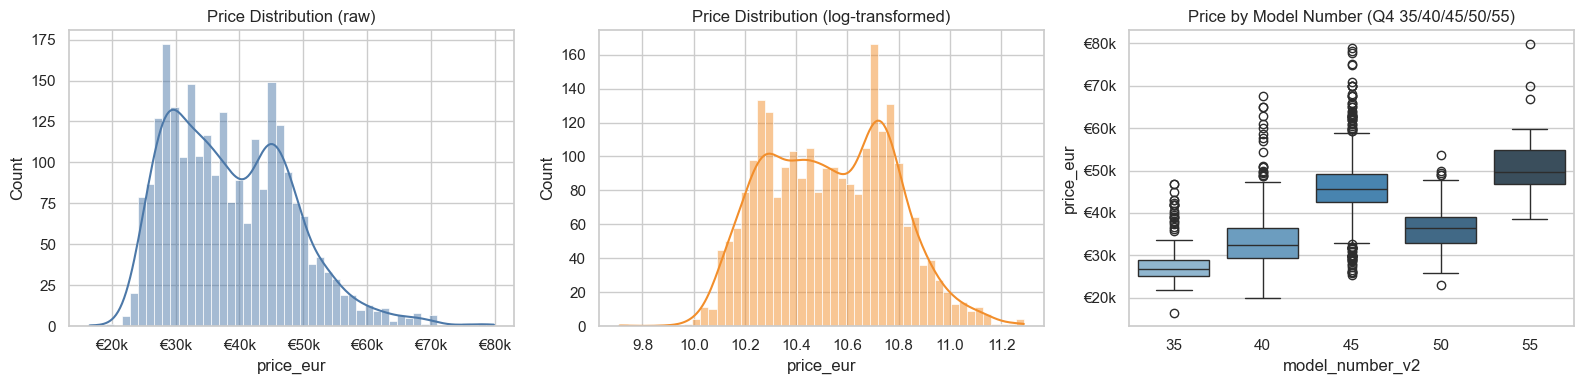

Skewness — raw: 0.643   log: 0.113
Using log-transformed target: True

Price by model_number_v2 (median):
model_number_v2
35    26885.0
40    32440.0
45    45609.5
50    36520.0
55    49567.5
Name: price_eur, dtype: Float64


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Raw price distribution
sns.histplot(y, bins=50, kde=True, ax=axes[0], color='#4C78A8')
axes[0].set_title('Price Distribution (raw)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x/1000:.0f}k'))

# Log-transformed
sns.histplot(np.log1p(y), bins=50, kde=True, ax=axes[1], color='#F28E2B')
axes[1].set_title('Price Distribution (log-transformed)')

# Price by model variant
if 'model_number_v2' in df.columns:
    plot_df = df[df['model_number_v2'].notna()].copy()
    plot_df['model_number_v2'] = plot_df['model_number_v2'].astype(str)
    order = sorted(plot_df['model_number_v2'].unique())
    sns.boxplot(data=plot_df, x='model_number_v2', y=TARGET, order=order,
                ax=axes[2], palette='Blues_d')
    axes[2].set_title('Price by Model Number (Q4 35/40/45/50/55)')
    axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x/1000:.0f}k'))

plt.tight_layout()
plt.show()

# Skewness comparison: raw vs log
from scipy import stats as scipy_stats
raw_skew = scipy_stats.skew(y.dropna())
log_skew = scipy_stats.skew(np.log1p(y.dropna()))
print(f'Skewness — raw: {raw_skew:.3f}   log: {log_skew:.3f}')
USE_LOG_TARGET = abs(log_skew) < abs(raw_skew)
print(f'Using log-transformed target: {USE_LOG_TARGET}')

if USE_LOG_TARGET:
    y_train = np.log1p(y)
else:
    y_train = y.copy()

print('\nPrice by model_number_v2 (median):')
print(df.groupby('model_number_v2')[TARGET].median().sort_index())

## 3. Preprocessing Pipeline

In [4]:
from sklearn.preprocessing import OneHotEncoder

# Ordinal encoding: model_number_v2 ordered by power tier
model_number_order = [['35', '40', '45', '50', '55']]

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

ordinal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OrdinalEncoder(
        categories=model_number_order,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    )),
])

nominal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False,
        min_frequency=5,
    )),
])

binary_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
])

preprocessor = ColumnTransformer([
    ('num',  numeric_pipe,  NUMERIC_FEATURES),
    ('ord',  ordinal_pipe,  CATEGORICAL_ORDINAL),
    ('nom',  nominal_pipe,  CATEGORICAL_NOMINAL),
    ('bin',  binary_pipe,   BINARY_FEATURES),
], remainder='drop', verbose_feature_names_out=True)

# Quick sanity check
from sklearn.utils.validation import check_is_fitted
X_check = preprocessor.fit_transform(X.head(10), y_train.head(10))
print(f'Preprocessor output shape for 10 rows: {X_check.shape}')
print('Preprocessing pipeline OK.')

Preprocessor output shape for 10 rows: (10, 46)
Preprocessing pipeline OK.


## 4. Baseline Model Comparison (5-Fold Cross-Validation)

In [5]:
from sklearn.metrics import make_scorer

def rmse_scorer(y_true, y_pred):
    if USE_LOG_TARGET:
        y_true_orig = np.expm1(y_true)
        y_pred_orig = np.expm1(y_pred)
    else:
        y_true_orig, y_pred_orig = y_true, y_pred
    return -np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))

def mae_scorer(y_true, y_pred):
    if USE_LOG_TARGET:
        y_true_orig = np.expm1(y_true)
        y_pred_orig = np.expm1(y_pred)
    else:
        y_true_orig, y_pred_orig = y_true, y_pred
    return -mean_absolute_error(y_true_orig, y_pred_orig)

def r2_scorer_fn(y_true, y_pred):
    if USE_LOG_TARGET:
        y_true_orig = np.expm1(y_true)
        y_pred_orig = np.expm1(y_pred)
    else:
        y_true_orig, y_pred_orig = y_true, y_pred
    return r2_score(y_true_orig, y_pred_orig)

scoring = {
    'rmse': make_scorer(rmse_scorer),
    'mae':  make_scorer(mae_scorer),
    'r2':   make_scorer(r2_scorer_fn),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    'Ridge Regression': Pipeline([
        ('pre', preprocessor),
        ('reg', Ridge(alpha=1.0))
    ]),
    'Random Forest': Pipeline([
        ('pre', preprocessor),
        ('reg', RandomForestRegressor(
            n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE
        ))
    ]),
    'XGBoost': Pipeline([
        ('pre', preprocessor),
        ('reg', XGBRegressor(
            n_estimators=500, learning_rate=0.05, max_depth=6,
            subsample=0.8, colsample_bytree=0.8,
            random_state=RANDOM_STATE, verbosity=0, n_jobs=-1
        ))
    ]),
    'LightGBM': Pipeline([
        ('pre', preprocessor),
        ('reg', LGBMRegressor(
            n_estimators=500, learning_rate=0.05, max_depth=6,
            num_leaves=63, subsample=0.8, colsample_bytree=0.8,
            random_state=RANDOM_STATE, verbosity=-1, n_jobs=-1
        ))
    ]),
    'HistGradientBoosting': Pipeline([
        ('pre', preprocessor),
        ('reg', HistGradientBoostingRegressor(
            max_iter=500, learning_rate=0.05, max_depth=6,
            random_state=RANDOM_STATE
        ))
    ]),
}

print('Running 5-fold cross-validation for 5 models...')
results = {}

for name, model in models.items():
    cv_results = cross_validate(
        model, X, y_train, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False
    )
    results[name] = {
        'RMSE (€)':  -cv_results['test_rmse'].mean(),
        'RMSE_std':  cv_results['test_rmse'].std(),
        'MAE (€)':   -cv_results['test_mae'].mean(),
        'R²':        cv_results['test_r2'].mean(),
        'R²_std':    cv_results['test_r2'].std(),
    }
    print(f'  {name:<22} RMSE=€{-cv_results["test_rmse"].mean():,.0f}  '
          f'MAE=€{-cv_results["test_mae"].mean():,.0f}  '
          f'R²={cv_results["test_r2"].mean():.4f}')

results_df = pd.DataFrame(results).T.sort_values('RMSE (€)')
print('\n── Baseline Comparison (sorted by RMSE) ──')
print(results_df[['RMSE (€)', 'MAE (€)', 'R²']].round({'RMSE (€)': 0, 'MAE (€)': 0, 'R²': 4}))

Running 5-fold cross-validation for 5 models...


  Ridge Regression       RMSE=€4,162  MAE=€2,698  R²=0.8161


  Random Forest          RMSE=€3,301  MAE=€2,032  R²=0.8836


  XGBoost                RMSE=€3,083  MAE=€1,879  R²=0.8983


  LightGBM               RMSE=€3,208  MAE=€2,018  R²=0.8900


  HistGradientBoosting   RMSE=€3,233  MAE=€2,031  R²=0.8881

── Baseline Comparison (sorted by RMSE) ──
                      RMSE (€)  MAE (€)      R²
XGBoost                 3083.0   1879.0  0.8983
LightGBM                3208.0   2018.0  0.8900
HistGradientBoosting    3233.0   2031.0  0.8881
Random Forest           3301.0   2032.0  0.8836
Ridge Regression        4162.0   2698.0  0.8161


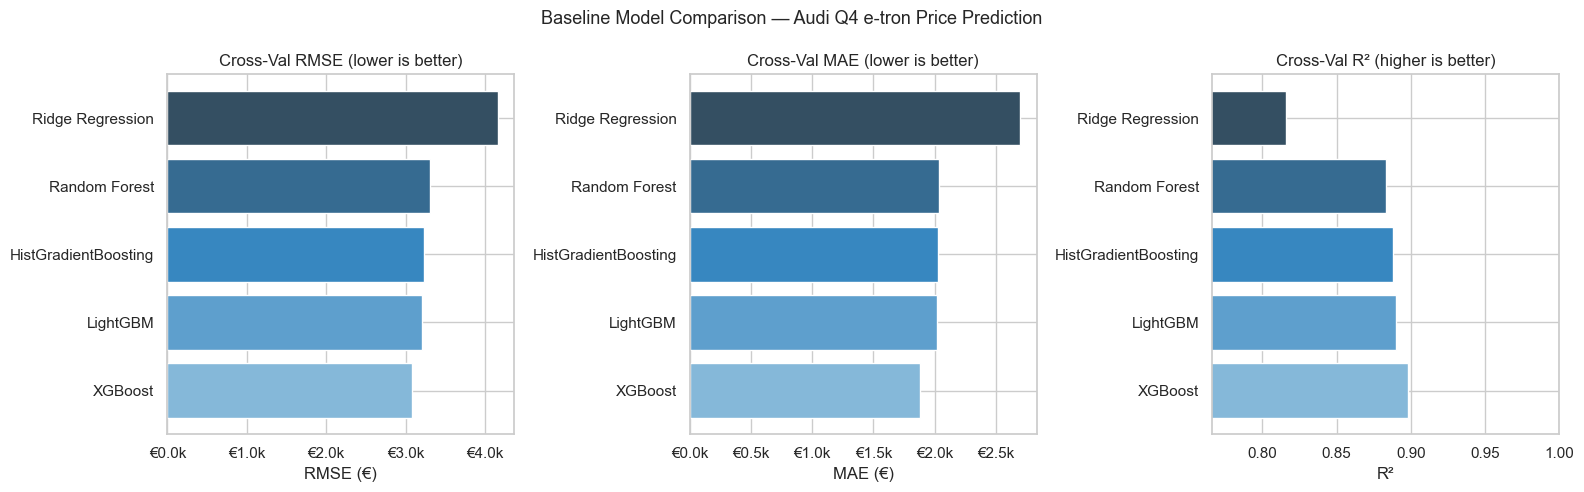


Top 2 models selected for Optuna tuning: ['XGBoost', 'LightGBM']


In [6]:
# ── Baseline comparison chart ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_names = results_df.index.tolist()
colors = sns.color_palette('Blues_d', len(model_names))

axes[0].barh(model_names, results_df['RMSE (€)'], color=colors)
axes[0].set_xlabel('RMSE (€)'); axes[0].set_title('Cross-Val RMSE (lower is better)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x/1000:.1f}k'))

axes[1].barh(model_names, results_df['MAE (€)'], color=colors)
axes[1].set_xlabel('MAE (€)'); axes[1].set_title('Cross-Val MAE (lower is better)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x/1000:.1f}k'))

axes[2].barh(model_names, results_df['R²'], color=colors)
axes[2].set_xlabel('R²'); axes[2].set_title('Cross-Val R² (higher is better)')
axes[2].set_xlim(max(0, results_df['R²'].min() - 0.05), 1.0)

plt.suptitle('Baseline Model Comparison — Audi Q4 e-tron Price Prediction', fontsize=13)
plt.tight_layout()
plt.show()

# Select top 2 models
top2_names = results_df.index[:2].tolist()
print(f'\nTop 2 models selected for Optuna tuning: {top2_names}')

## 5. Hyperparameter Tuning with Optuna (Top 2 Models)

In [7]:
N_TRIALS = 100

def make_preprocessor_fresh():
    """Return a new unfitted preprocessor (cloned from config above)."""
    return ColumnTransformer([
        ('num', Pipeline([('i', SimpleImputer(strategy='median')), ('s', StandardScaler())]),
         NUMERIC_FEATURES),
        ('ord', Pipeline([
            ('i', SimpleImputer(strategy='constant', fill_value='missing')),
            ('e', OrdinalEncoder(categories=model_number_order,
                                 handle_unknown='use_encoded_value', unknown_value=-1)),
        ]), CATEGORICAL_ORDINAL),
        ('nom', Pipeline([
            ('i', SimpleImputer(strategy='constant', fill_value='missing')),
            ('e', OneHotEncoder(handle_unknown='ignore', sparse_output=False, min_frequency=5)),
        ]), CATEGORICAL_NOMINAL),
        ('bin', Pipeline([('i', SimpleImputer(strategy='constant', fill_value=0))]),
         BINARY_FEATURES),
    ], remainder='drop')


def cv_rmse(model, X, y):
    """Return mean CV RMSE on original price scale."""
    scores = cross_val_score(
        model, X, y, cv=cv, scoring=make_scorer(rmse_scorer), n_jobs=-1
    )
    return -scores.mean()


# ── Build Optuna objectives based on top2_names ────────────────────────────
def objective_xgb(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.15, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 9),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0.0, 1.0),
    }
    model = Pipeline([
        ('pre', make_preprocessor_fresh()),
        ('reg', XGBRegressor(**params, random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)),
    ])
    return cv_rmse(model, X, y_train)


def objective_lgbm(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.15, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 9),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 200),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 80),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
    }
    model = Pipeline([
        ('pre', make_preprocessor_fresh()),
        ('reg', LGBMRegressor(**params, random_state=RANDOM_STATE, verbosity=-1, n_jobs=-1)),
    ])
    return cv_rmse(model, X, y_train)


def objective_rf(trial):
    params = {
        'n_estimators':  trial.suggest_int('n_estimators', 100, 600),
        'max_depth':     trial.suggest_int('max_depth', 5, 25),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 15),
        'max_features':  trial.suggest_float('max_features', 0.3, 1.0),
    }
    model = Pipeline([
        ('pre', make_preprocessor_fresh()),
        ('reg', RandomForestRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1)),
    ])
    return cv_rmse(model, X, y_train)


def objective_ridge(trial):
    alpha = trial.suggest_float('alpha', 0.01, 1000.0, log=True)
    model = Pipeline([
        ('pre', make_preprocessor_fresh()),
        ('reg', Ridge(alpha=alpha)),
    ])
    return cv_rmse(model, X, y_train)


def objective_hgb(trial):
    params = {
        'max_iter':          trial.suggest_int('max_iter', 200, 800),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.15, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 9),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 5, 80),
        'l2_regularization': trial.suggest_float('l2_regularization', 1e-4, 10.0, log=True),
    }
    model = Pipeline([
        ('pre', make_preprocessor_fresh()),
        ('reg', HistGradientBoostingRegressor(**params, random_state=RANDOM_STATE)),
    ])
    return cv_rmse(model, X, y_train)


OBJECTIVE_MAP = {
    'XGBoost':              objective_xgb,
    'LightGBM':             objective_lgbm,
    'Random Forest':        objective_rf,
    'Ridge Regression':     objective_ridge,
    'HistGradientBoosting': objective_hgb,
}

print(f'Starting Optuna tuning for top 2 models: {top2_names}')
print(f'({N_TRIALS} trials per model — this may take a few minutes)\n')

studies = {}
for name in top2_names:
    print(f'  Tuning {name}...')
    study = optuna.create_study(
        direction='minimize',
        sampler=TPESampler(seed=RANDOM_STATE),
        study_name=f'price_{name}'
    )
    study.optimize(OBJECTIVE_MAP[name], n_trials=N_TRIALS, show_progress_bar=True)
    studies[name] = study
    print(f'  → Best RMSE: €{study.best_value:,.0f}  Params: {study.best_params}\n')

print('Optuna tuning complete.')

Starting Optuna tuning for top 2 models: ['XGBoost', 'LightGBM']
(100 trials per model — this may take a few minutes)

  Tuning XGBoost...


  0%|          | 0/100 [00:00<?, ?it/s]

  → Best RMSE: €3,107  Params: {'n_estimators': 901, 'learning_rate': 0.05109895830092678, 'max_depth': 5, 'subsample': 0.5402745023696174, 'colsample_bytree': 0.6565865989704907, 'reg_alpha': 0.053643395546986855, 'reg_lambda': 0.006039023666952773, 'min_child_weight': 4, 'gamma': 0.0016986108501700755}

  Tuning LightGBM...


  0%|          | 0/100 [00:00<?, ?it/s]

  → Best RMSE: €3,084  Params: {'n_estimators': 982, 'learning_rate': 0.06970171994549877, 'max_depth': 6, 'num_leaves': 109, 'min_child_samples': 6, 'subsample': 0.9454224926918053, 'colsample_bytree': 0.6352380916443752, 'reg_alpha': 0.0018164678255528435, 'reg_lambda': 4.843768826126527}

Optuna tuning complete.


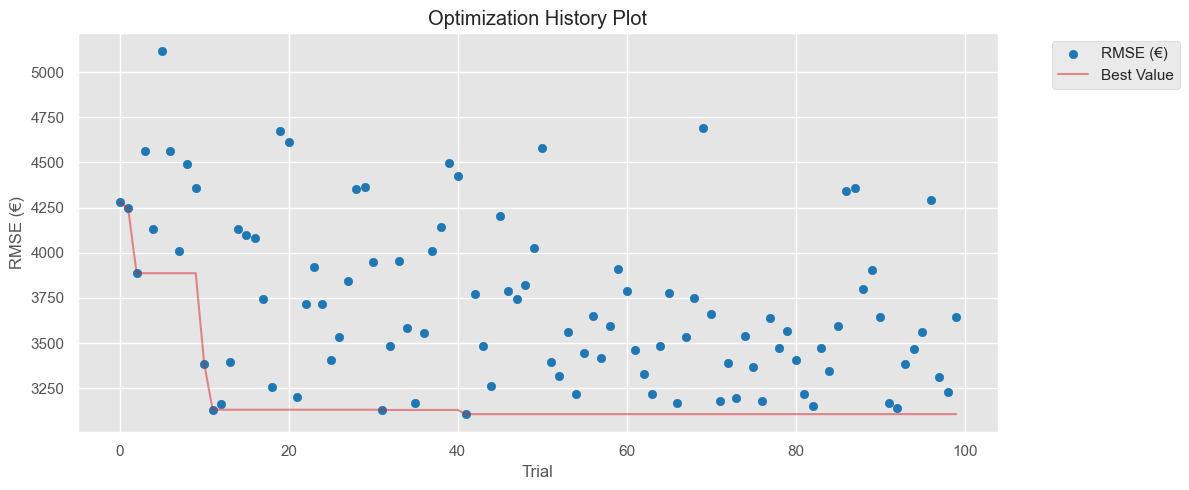

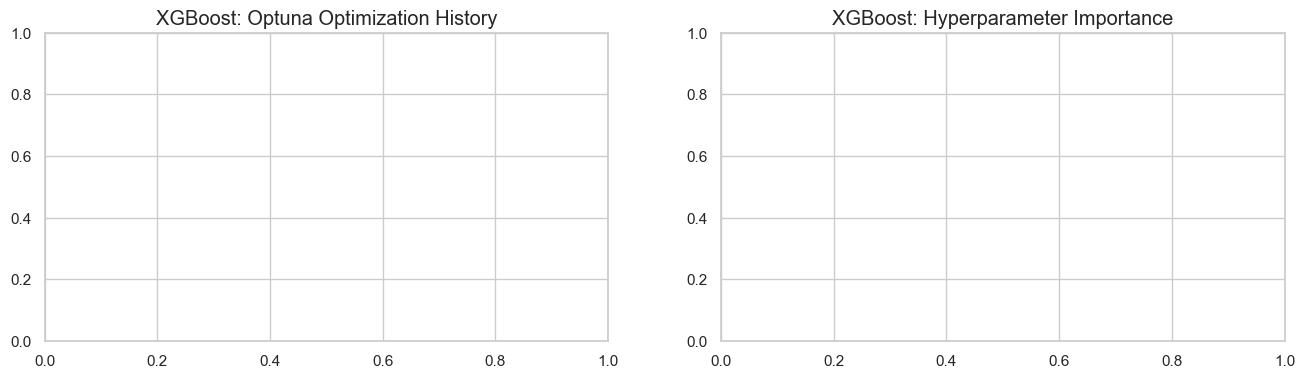

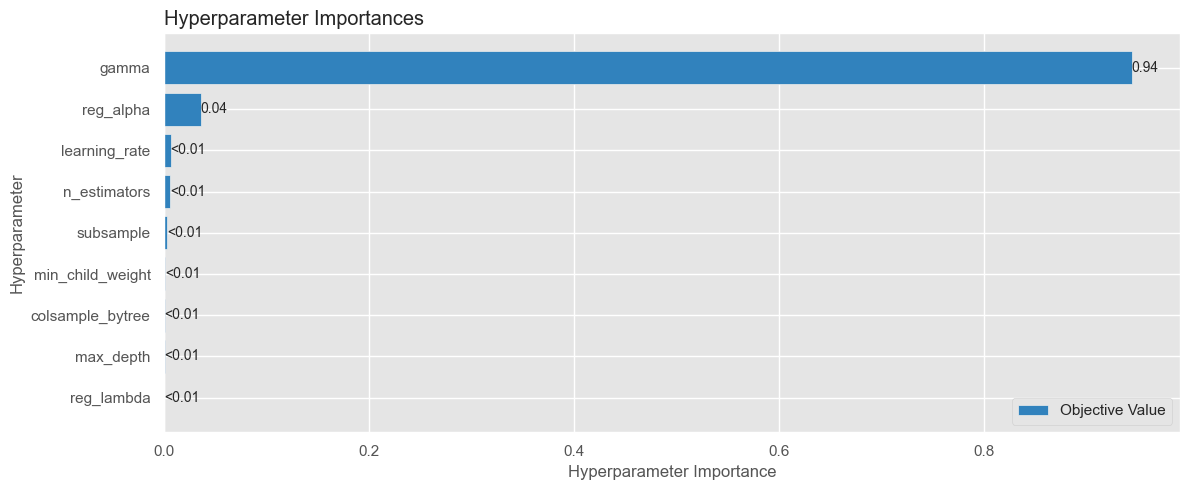

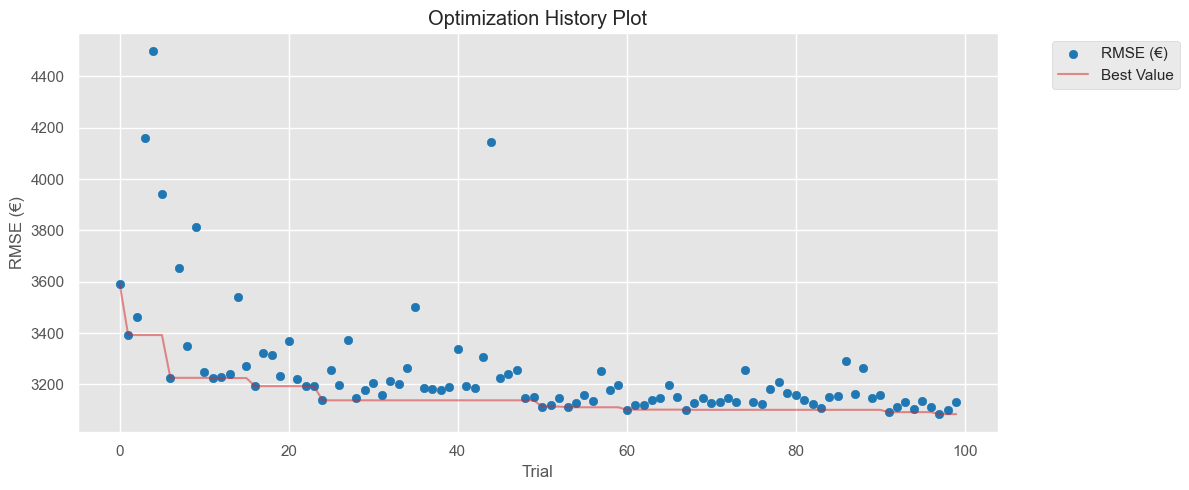

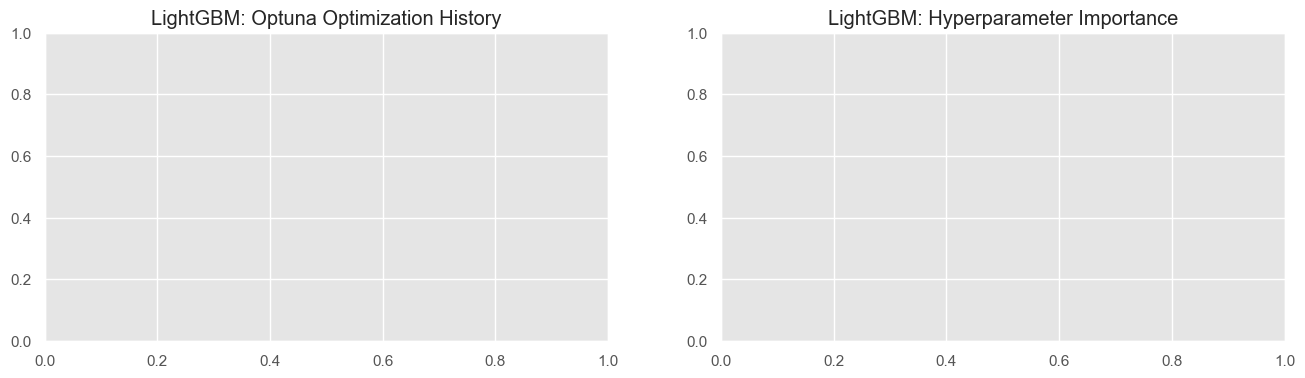

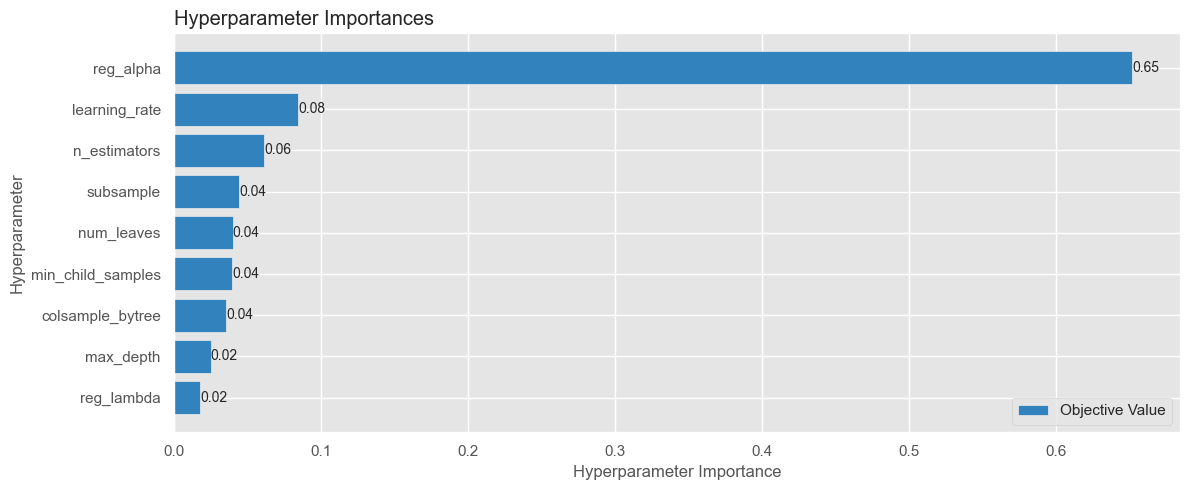

In [8]:
# ── Optuna visualizations ────────────────────────────────────────────────────
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
)

for name, study in studies.items():
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    plt.sca(axes[0])
    plot_optimization_history(study, target_name='RMSE (€)')
    axes[0].set_title(f'{name}: Optuna Optimization History')
    plt.sca(axes[1])
    plot_param_importances(study)
    axes[1].set_title(f'{name}: Hyperparameter Importance')
    plt.tight_layout()
    plt.show()

In [9]:
# ── Rebuild and fit tuned models on full dataset ─────────────────────────────
MODEL_BUILDERS = {
    'XGBoost':  lambda p: XGBRegressor(**p, random_state=RANDOM_STATE, verbosity=0, n_jobs=-1),
    'LightGBM': lambda p: LGBMRegressor(**p, random_state=RANDOM_STATE, verbosity=-1, n_jobs=-1),
    'Random Forest': lambda p: RandomForestRegressor(**p, random_state=RANDOM_STATE, n_jobs=-1),
    'Ridge Regression': lambda p: Ridge(**p),
    'HistGradientBoosting': lambda p: HistGradientBoostingRegressor(**p, random_state=RANDOM_STATE),
}

tuned_models = {}
tuned_cv_rmse = {}

for name in top2_names:
    best_params = studies[name].best_params
    regressor = MODEL_BUILDERS[name](best_params)
    model = Pipeline([('pre', make_preprocessor_fresh()), ('reg', regressor)])

    # Evaluate tuned model
    cv_scores = cross_val_score(
        model, X, y_train, cv=cv, scoring=make_scorer(rmse_scorer), n_jobs=-1
    )
    cv_rmse_val = -cv_scores.mean()
    tuned_cv_rmse[name] = cv_rmse_val

    # Fit on full data
    model.fit(X, y_train)
    tuned_models[name] = model
    print(f'{name} tuned CV RMSE: €{cv_rmse_val:,.0f}  (was €{results[name]["RMSE (€)"]:,.0f})')

# Sort by CV RMSE
model_rank = sorted(tuned_models.keys(), key=lambda n: tuned_cv_rmse[n])
best_model_name  = model_rank[0]
second_model_name = model_rank[1]
print(f'\n#1 model: {best_model_name}  (RMSE €{tuned_cv_rmse[best_model_name]:,.0f})')
print(f'#2 model: {second_model_name}  (RMSE €{tuned_cv_rmse[second_model_name]:,.0f})')

XGBoost tuned CV RMSE: €3,107  (was €3,083)


LightGBM tuned CV RMSE: €3,084  (was €3,208)

#1 model: LightGBM  (RMSE €3,084)
#2 model: XGBoost  (RMSE €3,107)


## 6. Post-Tuning Analysis — Residuals & Prediction Quality


── LightGBM (OOF) ──────────────────────────────────────────
  RMSE:  €3,095
  MAE:   €1,887
  R²:    0.8987
  MAPE:  4.79%


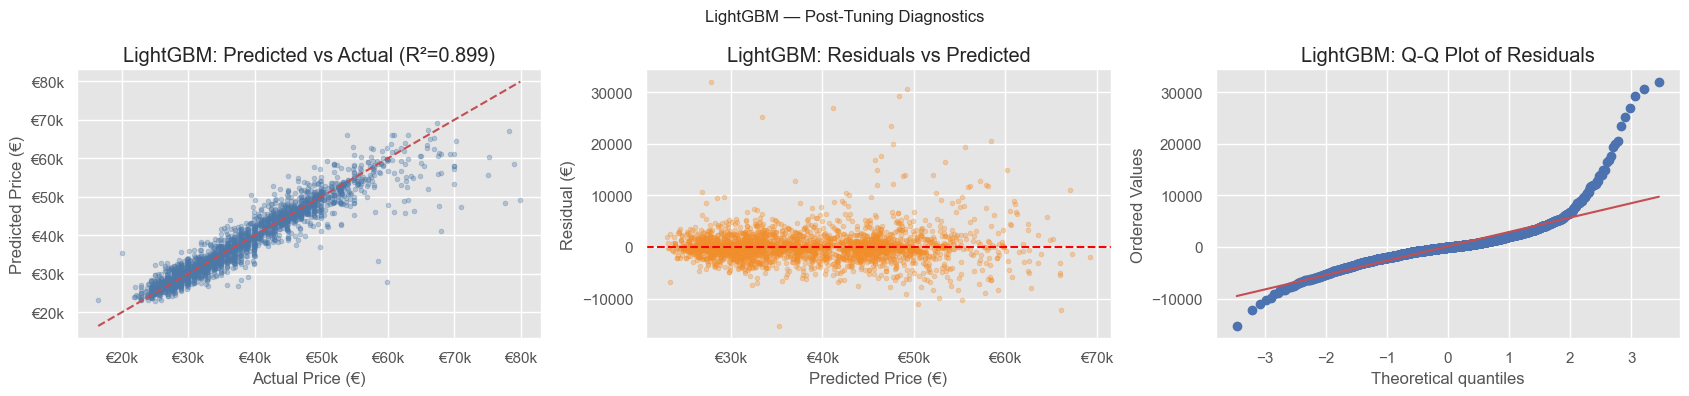

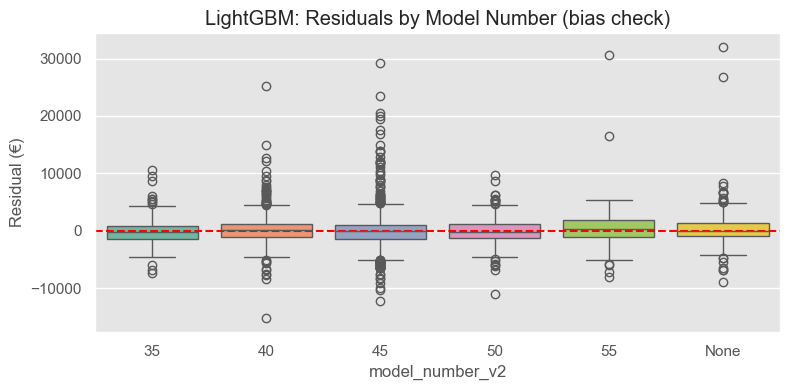


── XGBoost (OOF) ──────────────────────────────────────────
  RMSE:  €3,117
  MAE:   €1,939
  R²:    0.8972
  MAPE:  4.91%


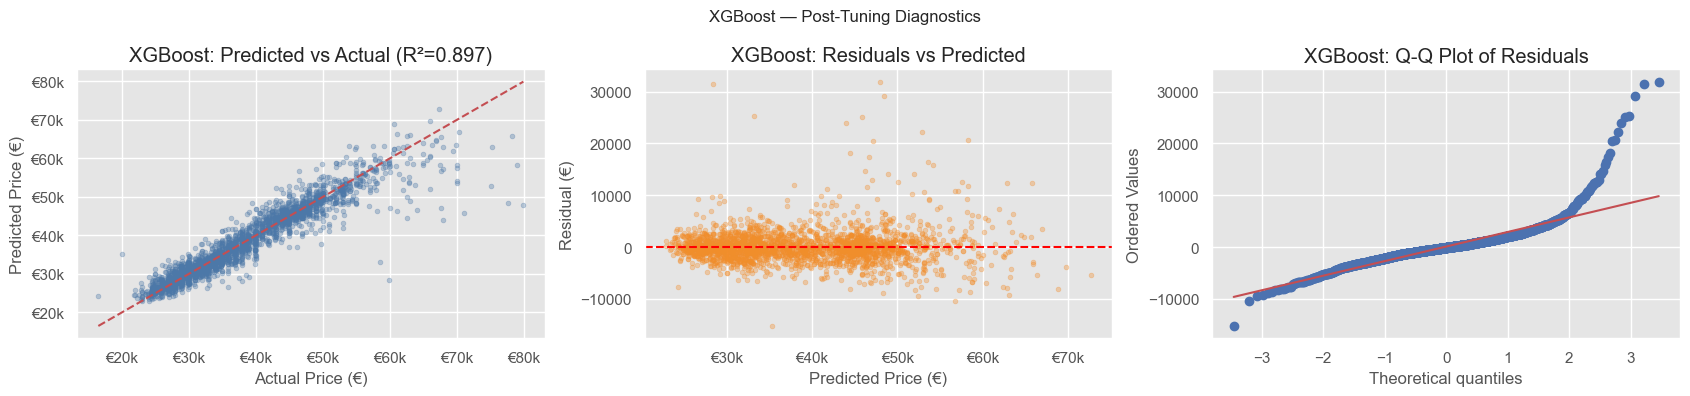

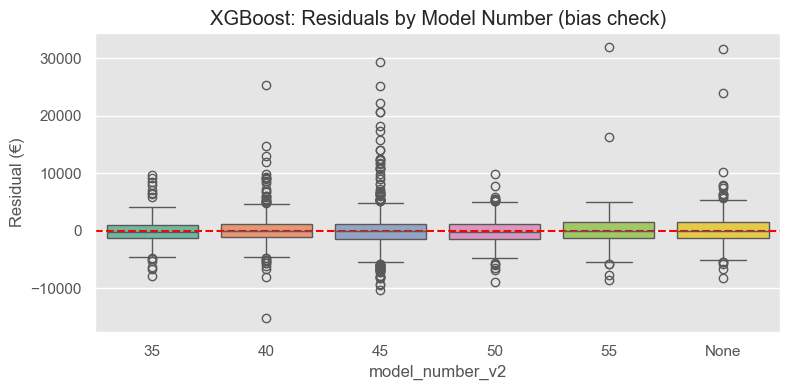

In [10]:
from sklearn.model_selection import cross_val_predict
import scipy.stats as scipy_stats

for name in [best_model_name, second_model_name]:
    model = tuned_models[name]

    # Out-of-fold predictions
    best_params = studies[name].best_params
    regressor_for_cv = MODEL_BUILDERS[name](best_params)
    oof_model = Pipeline([('pre', make_preprocessor_fresh()), ('reg', regressor_for_cv)])
    y_oof_log = cross_val_predict(oof_model, X, y_train, cv=cv, n_jobs=-1)

    if USE_LOG_TARGET:
        y_oof = np.expm1(y_oof_log)
        y_true = np.expm1(y_train)
    else:
        y_oof  = y_oof_log
        y_true = y_train.copy()

    residuals = y_true - y_oof
    rmse_oof  = np.sqrt(mean_squared_error(y_true, y_oof))
    mae_oof   = mean_absolute_error(y_true, y_oof)
    r2_oof    = r2_score(y_true, y_oof)
    mape_oof  = (np.abs(residuals) / y_true).mean() * 100

    print(f'\n── {name} (OOF) ──────────────────────────────────────────')
    print(f'  RMSE:  €{rmse_oof:,.0f}')
    print(f'  MAE:   €{mae_oof:,.0f}')
    print(f'  R²:    {r2_oof:.4f}')
    print(f'  MAPE:  {mape_oof:.2f}%')

    fig, axes = plt.subplots(1, 3, figsize=(17, 4))

    # Predicted vs Actual
    axes[0].scatter(y_true, y_oof, alpha=0.35, s=12, color='#4C78A8')
    lims = [min(y_true.min(), y_oof.min()), max(y_true.max(), y_oof.max())]
    axes[0].plot(lims, lims, 'r--', lw=1.5)
    axes[0].set_xlabel('Actual Price (€)'); axes[0].set_ylabel('Predicted Price (€)')
    axes[0].set_title(f'{name}: Predicted vs Actual (R²={r2_oof:.3f})')
    axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x/1000:.0f}k'))
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x/1000:.0f}k'))

    # Residuals vs Predicted
    axes[1].scatter(y_oof, residuals, alpha=0.35, s=12, color='#F28E2B')
    axes[1].axhline(0, color='red', lw=1.5, linestyle='--')
    axes[1].set_xlabel('Predicted Price (€)'); axes[1].set_ylabel('Residual (€)')
    axes[1].set_title(f'{name}: Residuals vs Predicted')
    axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x/1000:.0f}k'))

    # Q-Q plot
    scipy_stats.probplot(residuals, dist='norm', plot=axes[2])
    axes[2].set_title(f'{name}: Q-Q Plot of Residuals')

    plt.suptitle(f'{name} — Post-Tuning Diagnostics', fontsize=12)
    plt.tight_layout()
    plt.show()

    # Residuals by model variant
    if 'model_number_v2' in df.columns:
        diag_df = pd.DataFrame({
            'model_number_v2': df['model_number_v2'].astype(str),
            'residual': residuals.values
        }).dropna()
        plt.figure(figsize=(8, 4))
        order = sorted(diag_df['model_number_v2'].unique())
        sns.boxplot(data=diag_df, x='model_number_v2', y='residual', order=order, palette='Set2')
        plt.axhline(0, color='red', lw=1.5, linestyle='--')
        plt.title(f'{name}: Residuals by Model Number (bias check)')
        plt.ylabel('Residual (€)')
        plt.tight_layout()
        plt.show()

## 7. SHAP Feature Importance (Best Model)

In [11]:
# Fit a fresh version on full data for SHAP (need raw estimator, not nested pipeline)
best_name   = best_model_name
best_model  = tuned_models[best_name]

# Transform X for SHAP (extract preprocessed array)
pre_fitted = best_model.named_steps['pre']
X_transformed = pre_fitted.transform(X)

# Feature names after transformation
try:
    feature_names_out = pre_fitted.get_feature_names_out()
    # Simplify names
    feature_names_clean = [
        n.split('__')[-1] for n in feature_names_out
    ]
except Exception:
    feature_names_clean = [f'f{i}' for i in range(X_transformed.shape[1])]

# SHAP explainer
estimator = best_model.named_steps['reg']

if best_name in ('XGBoost', 'LightGBM', 'Random Forest'):
    explainer = shap.TreeExplainer(estimator)
    shap_values = explainer.shap_values(X_transformed)
else:
    explainer = shap.LinearExplainer(estimator, X_transformed)
    shap_values = explainer.shap_values(X_transformed)

print(f'SHAP values computed for {best_name}. Shape: {np.array(shap_values).shape}')

SHAP values computed for LightGBM. Shape: (2516, 69)


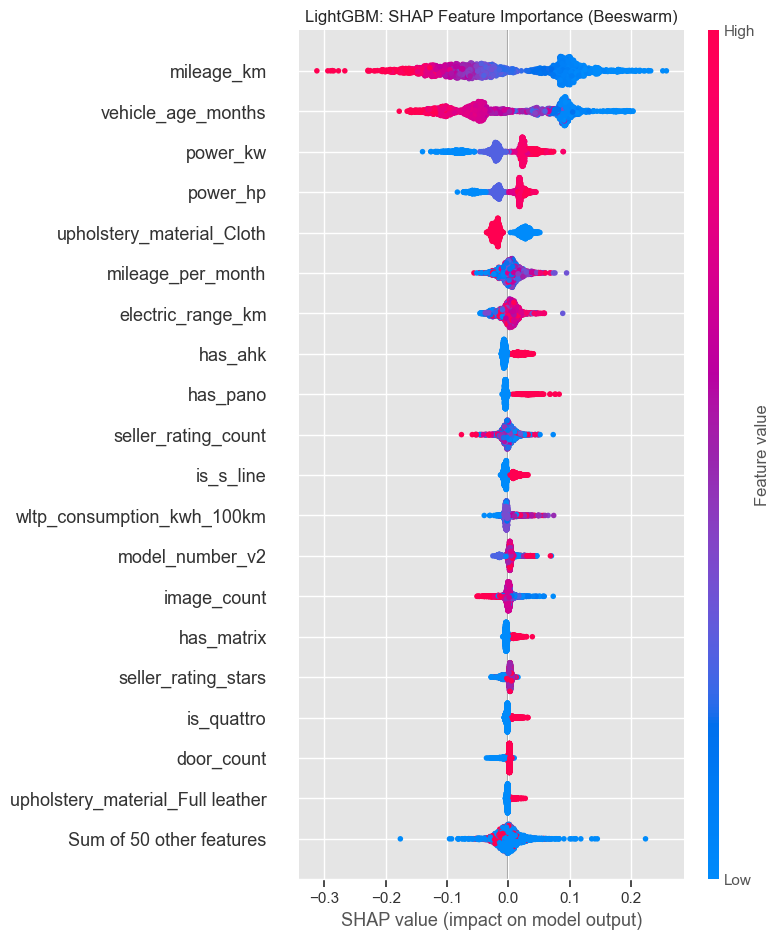

In [12]:
# ── SHAP Beeswarm plot (top 20 features) ─────────────────────────────────────
shap_exp = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value if hasattr(explainer, 'expected_value') else 0,
    data=X_transformed,
    feature_names=feature_names_clean
)

plt.figure(figsize=(11, 8))
shap.plots.beeswarm(shap_exp, max_display=20, show=False)
plt.title(f'{best_name}: SHAP Feature Importance (Beeswarm)', fontsize=12)
plt.tight_layout()
plt.show()

Top 3 features by mean |SHAP|: ['mileage_km', 'vehicle_age_months', 'power_kw']


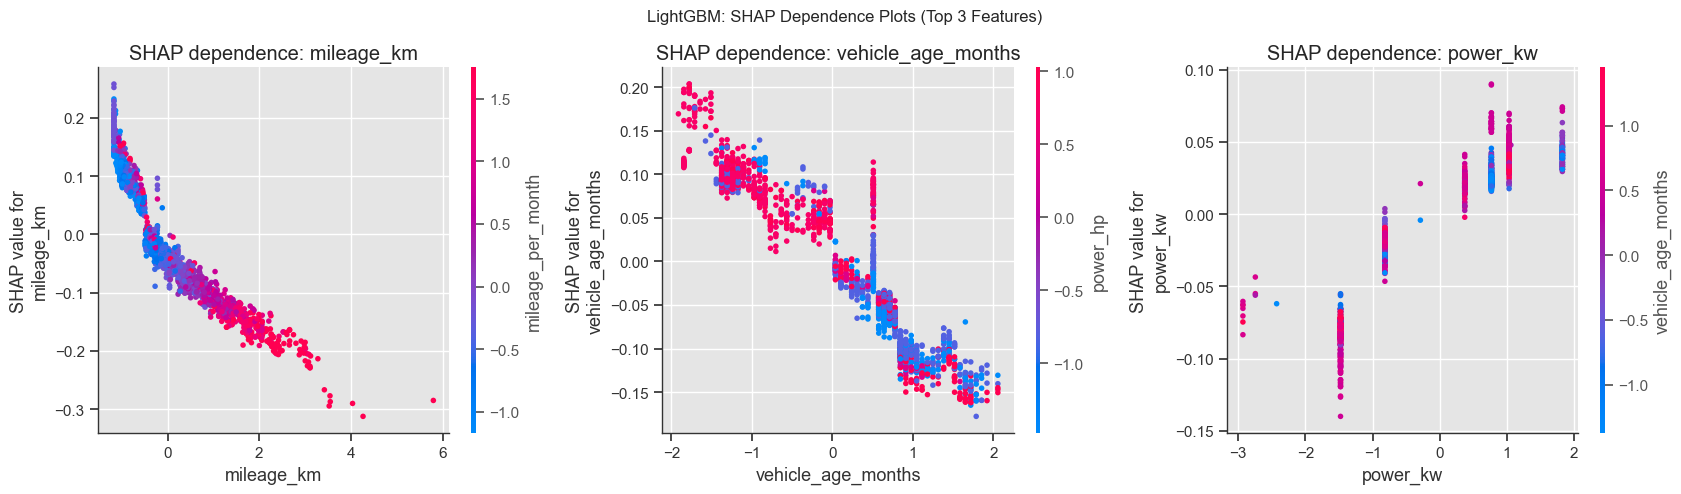

In [13]:
# ── SHAP Dependence plots for top 3 features ─────────────────────────────────
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top3_idx = mean_abs_shap.argsort()[::-1][:3]
top3_names = [feature_names_clean[i] for i in top3_idx]
print(f'Top 3 features by mean |SHAP|: {top3_names}')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, idx, feat_name in zip(axes, top3_idx, top3_names):
    shap.dependence_plot(
        idx, shap_values, X_transformed,
        feature_names=feature_names_clean,
        ax=ax, show=False
    )
    ax.set_title(f'SHAP dependence: {feat_name}')

plt.suptitle(f'{best_name}: SHAP Dependence Plots (Top 3 Features)', fontsize=12)
plt.tight_layout()
plt.show()

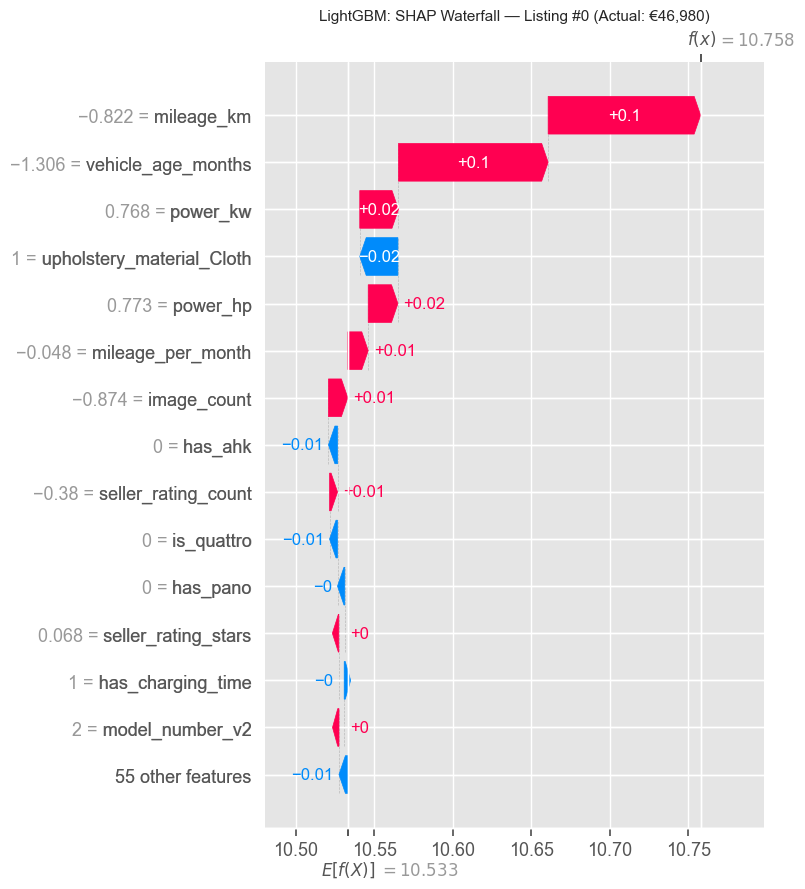

In [14]:
# ── SHAP Waterfall for a sample listing ──────────────────────────────────────
sample_idx = 0
plt.figure(figsize=(11, 6))
shap.plots.waterfall(shap_exp[sample_idx], max_display=15, show=False)
plt.title(f'{best_name}: SHAP Waterfall — Listing #{sample_idx} '
          f'(Actual: €{y.iloc[sample_idx]:,.0f})', fontsize=11)
plt.tight_layout()
plt.show()

## 8. Final Model Summary & Save

In [15]:
# ── Final comparison table ───────────────────────────────────────────────────
summary_rows = []
for name in top2_names:
    baseline_rmse = results[name]['RMSE (€)']
    tuned_rmse    = tuned_cv_rmse[name]
    summary_rows.append({
        'Model':          name,
        'Baseline RMSE':  f'€{baseline_rmse:,.0f}',
        'Tuned RMSE':     f'€{tuned_rmse:,.0f}',
        'Improvement':    f'€{baseline_rmse - tuned_rmse:,.0f}',
        'Rank':           model_rank.index(name) + 1,
    })
print('── Final Model Summary ──────────────────────────────────')
print(pd.DataFrame(summary_rows).to_string(index=False))

# ── Save models + metadata ───────────────────────────────────────────────────
joblib.dump(tuned_models[model_rank[0]], MODELS_DIR / 'price_model_best1.pkl')
joblib.dump(tuned_models[model_rank[1]], MODELS_DIR / 'price_model_best2.pkl')

# Save feature column lists for Deal Finder notebook
price_meta = {
    'feature_cols':        ALL_FEATURES,
    'numeric_features':    NUMERIC_FEATURES,
    'categorical_ordinal': CATEGORICAL_ORDINAL,
    'categorical_nominal': CATEGORICAL_NOMINAL,
    'binary_features':     BINARY_FEATURES,
    'target':              TARGET,
    'use_log_target':      bool(USE_LOG_TARGET),
    'best_model_name':     model_rank[0],
    'second_model_name':   model_rank[1],
    'tuned_rmse_best':     tuned_cv_rmse[model_rank[0]],
    'tuned_rmse_second':   tuned_cv_rmse[model_rank[1]],
    'model_number_order':  model_number_order[0],
    'trained_at':          datetime.now().isoformat(),
}

with open(MODELS_DIR / 'price_model_meta.json', 'w') as f:
    json.dump(price_meta, f, indent=2)

print(f'\nSaved:')
print(f'  {MODELS_DIR}/price_model_best1.pkl  → {model_rank[0]}')
print(f'  {MODELS_DIR}/price_model_best2.pkl  → {model_rank[1]}')
print(f'  {MODELS_DIR}/price_model_meta.json')
print('\nNotebook complete. Run 01_time_to_sell_model.ipynb next, then 03_deal_finder.ipynb.')

── Final Model Summary ──────────────────────────────────
   Model Baseline RMSE Tuned RMSE Improvement  Rank
 XGBoost        €3,083     €3,107        €-24     2
LightGBM        €3,208     €3,084        €123     1

Saved:
  saved_models/price_model_best1.pkl  → LightGBM
  saved_models/price_model_best2.pkl  → XGBoost
  saved_models/price_model_meta.json

Notebook complete. Run 01_time_to_sell_model.ipynb next, then 03_deal_finder.ipynb.
